# 🚀 NASA CMAPSS Veri Seti - Model Karşılaştırma Analizi

Bu notebook'ta 4 farklı CMAPSS dataseti üzerinde çeşitli makine öğrenmesi ve deep learning modellerini karşılaştırıyoruz.

## Datasets:
- **FD001**: Tek operasyon modu, tek arıza tipi
- **FD002**: 6 operasyon modu, tek arıza tipi  
- **FD003**: Tek operasyon modu, 2 arıza tipi
- **FD004**: 6 operasyon modu, 2 arıza tipi

## Modeller:
1. **XGBoost** (Baseline - mevcut)
2. **Random Forest**
3. **SVR (Support Vector Regression)**
4. **Linear Regression**
5. **LSTM (Deep Learning)**
6. **GRU (Deep Learning)**
7. **CNN-LSTM Hybrid (Deep Learning)**

## 1. Kütüphaneleri Yükle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression

# XGBoost
from xgboost import XGBRegressor

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Joblib
import joblib

# Zaman takibi
import time

print("✅ Kütüphaneler yüklendi")
print(f"TensorFlow version: {tf.__version__}")

✅ Kütüphaneler yüklendi
TensorFlow version: 2.15.0


## 2. Veri Yükleme ve Ön İşleme Fonksiyonları

In [2]:
# Sütun isimleri
sensor_columns = ['sensor_' + str(i) for i in range(1, 22)]
setting_columns = ['setting_' + str(i) for i in range(1, 4)]
column_names = ['unit_number', 'time_in_cycles'] + setting_columns + sensor_columns

def load_cmapss_data(dataset_name='FD001', data_dir='CMaps'):
    """
    CMAPSS veri setini yükler ve RUL hesaplar
    
    Parameters:
    - dataset_name: 'FD001', 'FD002', 'FD003', 'FD004'
    - data_dir: Veri klasörü yolu
    
    Returns:
    - train_df: Eğitim dataframe (RUL ile)
    - test_df: Test dataframe
    - rul_df: Test RUL değerleri
    """
    # Train verisi
    train_path = f'{data_dir}/train_{dataset_name}.txt'
    train_df = pd.read_csv(train_path, sep='\s+', header=None, names=column_names)
    
    # Test verisi
    test_path = f'{data_dir}/test_{dataset_name}.txt'
    test_df = pd.read_csv(test_path, sep='\s+', header=None, names=column_names)
    
    # RUL değerleri
    rul_path = f'{data_dir}/RUL_{dataset_name}.txt'
    rul_df = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])
    
    # Train için RUL hesapla
    train_df['RUL'] = train_df.groupby('unit_number')['time_in_cycles'].transform(max) - train_df['time_in_cycles']
    
    # Test için RUL ekle (son cycle'a göre)
    test_df['max_cycle'] = test_df.groupby('unit_number')['time_in_cycles'].transform(max)
    test_last = test_df.groupby('unit_number').last().reset_index()
    test_last['RUL'] = rul_df['RUL'].values
    
    return train_df, test_df, test_last, rul_df

print("✅ Veri yükleme fonksiyonları hazır")

✅ Veri yükleme fonksiyonları hazır


## 3. Veri Setlerini Yükle

In [3]:
datasets = {}

for ds_name in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f"\n📂 {ds_name} yükleniyor...")
    train_df, test_df, test_last, rul_df = load_cmapss_data(ds_name)
    
    datasets[ds_name] = {
        'train': train_df,
        'test': test_df,
        'test_last': test_last,
        'rul': rul_df
    }
    
    print(f"   Train: {len(train_df)} satır, {train_df['unit_number'].nunique()} motor")
    print(f"   Test: {len(test_df)} satır, {test_df['unit_number'].nunique()} motor")
    print(f"   RUL range: {train_df['RUL'].min():.0f} - {train_df['RUL'].max():.0f}")

print("\n✅ Tüm veri setleri yüklendi!")


📂 FD001 yükleniyor...
   Train: 20631 satır, 100 motor
   Test: 13096 satır, 100 motor
   RUL range: 0 - 361

📂 FD002 yükleniyor...
   Train: 53759 satır, 260 motor
   Test: 33991 satır, 259 motor
   RUL range: 0 - 377

📂 FD003 yükleniyor...
   Train: 24720 satır, 100 motor
   Test: 16596 satır, 100 motor
   RUL range: 0 - 524

📂 FD004 yükleniyor...
   Train: 61249 satır, 249 motor
   Test: 41214 satır, 248 motor
   RUL range: 0 - 542

✅ Tüm veri setleri yüklendi!


## 4. Feature Engineering

In [4]:
def prepare_features(df, feature_cols=None):
    """Özellikleri hazırlar (sabit değerleri kaldır)"""
    if feature_cols is None:
        feature_cols = [col for col in df.columns if 'sensor' in col or 'setting' in col]
    
    # Sabit değerleri kaldır (variance = 0)
    variance = df[feature_cols].var()
    feature_cols = variance[variance > 0.01].index.tolist()
    
    return feature_cols

# Her dataset için feature'ları belirle
for ds_name in datasets.keys():
    train_df = datasets[ds_name]['train']
    feature_cols = prepare_features(train_df)
    datasets[ds_name]['features'] = feature_cols
    print(f"{ds_name}: {len(feature_cols)} özellik seçildi")

print("\n✅ Feature engineering tamamlandı")

FD001: 11 özellik seçildi
FD002: 23 özellik seçildi
FD003: 13 özellik seçildi
FD004: 23 özellik seçildi

✅ Feature engineering tamamlandı


## 5. ML Model Tanımları

In [5]:
def get_ml_models():
    """Geleneksel makine öğrenmesi modellerini döndürür"""
    models = {
        'Linear Regression': LinearRegression(),
        
        'Random Forest': RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        ),
        
        'XGBoost': XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ),
        
        'SVR': SVR(
            kernel='rbf',
            C=100,
            gamma='scale'
        )
    }
    
    return models

print("✅ ML modelleri tanımlandı")

✅ ML modelleri tanımlandı


## 6. Deep Learning Model Tanımları

In [6]:
def create_lstm_model(input_shape, units=64):
    """LSTM modeli oluşturur"""
    model = Sequential([
        LSTM(units, activation='tanh', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units//2, activation='tanh'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def create_gru_model(input_shape, units=64):
    """GRU modeli oluşturur"""
    model = Sequential([
        GRU(units, activation='tanh', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(units//2, activation='tanh'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def create_cnn_lstm_model(input_shape, filters=64, units=50):
    """CNN-LSTM hybrid model oluşturur"""
    model = Sequential([
        Conv1D(filters=filters, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        Conv1D(filters=filters//2, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        LSTM(units, activation='tanh'),
        Dropout(0.2),
        
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def create_sequences(df, feature_cols, sequence_length=30):
    """Zaman serisi sequence'ları oluşturur (Deep Learning için)"""
    X_seq = []
    y_seq = []
    
    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit].sort_values('time_in_cycles')
        X_unit = unit_data[feature_cols].values
        y_unit = unit_data['RUL'].values
        
        for i in range(sequence_length, len(X_unit)):
            X_seq.append(X_unit[i-sequence_length:i])
            y_seq.append(y_unit[i])
    
    return np.array(X_seq), np.array(y_seq)

print("✅ Deep Learning modelleri tanımlandı")

✅ Deep Learning modelleri tanımlandı


## 6.1 Evolved Modeller (Attention + Bidirectional)


In [7]:
class Attention(tf.keras.layers.Layer):
    def __init__(self, **kwargs): super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

def create_evolved_lstm(input_shape):
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Dropout(0.2)(x)
    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Attention()(x)
    x = Dense(32, activation="relu")(x)
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

def create_evolved_gru(input_shape):
    inputs = Input(shape=input_shape)
    x = Bidirectional(GRU(64, return_sequences=True))(inputs)
    x = Dropout(0.2)(x)
    x = Bidirectional(GRU(32, return_sequences=True))(x)
    x = Attention()(x)
    x = Dense(32, activation="relu")(x)
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

print("✅ Evrilmiş (Attention) modeller tanımlandı")

✅ Evrilmiş (Attention) modeller tanımlandı


## 7. Model Eğitim ve Değerlendirme - ML Modelleri

In [8]:
# Sonuçları saklamak için liste
all_results = []

# Parametreler
TEST_SIZE = 0.2
RANDOM_STATE = 42

print("🚀 ML Modelleri Eğitiliyor...\n")
print("="*80)

for ds_name in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f"\n📊 Dataset: {ds_name}")
    print("-" * 80)
    
    # Veriyi hazırla
    train_df = datasets[ds_name]['train']
    feature_cols = datasets[ds_name]['features']
    
    X = train_df[feature_cols].values
    y = train_df['RUL'].values
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ML modellerini eğit
    ml_models = get_ml_models()
    
    for model_name, model in ml_models.items():
        print(f"   🔧 {model_name} eğitiliyor...")
        
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        train_time = time.time() - start_time
        
        # Tahmin
        y_pred = model.predict(X_test_scaled)
        
        # Değerlendirme
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        results = {
            'Model': model_name,
            'Dataset': ds_name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Train_Time': train_time
        }
        all_results.append(results)
        
        print(f"      ✅ MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f} | Time: {train_time:.2f}s")

print("\n" + "="*80)
print("✅ ML modelleri tamamlandı!")

🚀 ML Modelleri Eğitiliyor...


📊 Dataset: FD001
--------------------------------------------------------------------------------
   🔧 Linear Regression eğitiliyor...
      ✅ MAE: 34.16 | RMSE: 44.50 | R²: 0.567 | Time: 0.00s
   🔧 Random Forest eğitiliyor...
      ✅ MAE: 29.71 | RMSE: 41.54 | R²: 0.622 | Time: 1.19s
   🔧 XGBoost eğitiliyor...
      ✅ MAE: 30.26 | RMSE: 42.15 | R²: 0.611 | Time: 0.18s
   🔧 SVR eğitiliyor...
      ✅ MAE: 29.32 | RMSE: 41.79 | R²: 0.618 | Time: 5.79s

📊 Dataset: FD002
--------------------------------------------------------------------------------
   🔧 Linear Regression eğitiliyor...
      ✅ MAE: 34.71 | RMSE: 44.92 | R²: 0.570 | Time: 0.01s
   🔧 Random Forest eğitiliyor...
      ✅ MAE: 31.68 | RMSE: 43.18 | R²: 0.603 | Time: 4.81s
   🔧 XGBoost eğitiliyor...
      ✅ MAE: 31.71 | RMSE: 43.13 | R²: 0.604 | Time: 0.23s
   🔧 SVR eğitiliyor...
      ✅ MAE: 33.79 | RMSE: 45.52 | R²: 0.558 | Time: 40.77s

📊 Dataset: FD003
-----------------------------------------

## 8. Deep Learning Modelleri Eğitimi

In [12]:
# Deep Learning parametreleri
SEQUENCE_LENGTH = 30
EPOCHS = 50
BATCH_SIZE = 256
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

print("🧠 Deep Learning Modelleri Eğitiliyor...")
print("="*80)

for ds_name in ["FD001", "FD002", "FD003", "FD004"]:
    print(f"🧠 Deep Learning - Dataset: {ds_name}")
    print("-" * 80)
    
    # Veriyi hazırla
    train_df = datasets[ds_name]["train"]
    feature_cols = datasets[ds_name]["features"]
    
    # Sequence oluştur
    print("   📦 Sequencelar oluşturuluyor...")
    X_seq, y_seq = create_sequences(train_df, feature_cols, SEQUENCE_LENGTH)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_seq, y_seq, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = X_train.reshape(-1, X_train.shape[-1])
    X_train_scaled = scaler.fit_transform(X_train_scaled)
    X_train_scaled = X_train_scaled.reshape(X_train.shape)
    
    X_test_scaled = X_test.reshape(-1, X_test.shape[-1])
    X_test_scaled = scaler.transform(X_test_scaled)
    X_test_scaled = X_test_scaled.reshape(X_test.shape)
    
    # İŞTE BURADA TANIMLANIYOR
    input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
    
    # Deep Learning modelleri
    dl_models = {
        "LSTM": create_lstm_model(input_shape),
        "GRU": create_gru_model(input_shape),
        "CNN-LSTM": create_cnn_lstm_model(input_shape),
        "Evolved-LSTM": create_evolved_lstm(input_shape),
        "Evolved-GRU": create_evolved_gru(input_shape)
    }
    
    for model_name, model in dl_models.items():
        print(f" {model_name} eğitiliyor...")
        start_time = time.time()
        history = model.fit(
            X_train_scaled, y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.2,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )
        train_time = time.time() - start_time
        y_pred = model.predict(X_test_scaled, verbose=0).flatten()
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        all_results.append({
            "Model": model_name, "Dataset": ds_name, "MAE": mae, 
            "RMSE": rmse, "R2": r2, "Train_Time": train_time, 
            "Epochs": len(history.history["loss"])
        })
        print(f"      ✅ MAE: {mae:.2f} | R²: {r2:.3f}")

print("✅ Tüm Deep Learning eğitimleri tamamlandı!")

🧠 Deep Learning Modelleri Eğitiliyor...
🧠 Deep Learning - Dataset: FD001
--------------------------------------------------------------------------------
   📦 Sequencelar oluşturuluyor...
 LSTM eğitiliyor...
      ✅ MAE: 12.41 | R²: 0.912
 GRU eğitiliyor...
      ✅ MAE: 17.89 | R²: 0.829
 CNN-LSTM eğitiliyor...
      ✅ MAE: 14.83 | R²: 0.900
 Evolved-LSTM eğitiliyor...
      ✅ MAE: 12.40 | R²: 0.910
 Evolved-GRU eğitiliyor...
      ✅ MAE: 16.09 | R²: 0.854
🧠 Deep Learning - Dataset: FD002
--------------------------------------------------------------------------------
   📦 Sequencelar oluşturuluyor...
 LSTM eğitiliyor...
      ✅ MAE: 50.57 | R²: -0.000
 GRU eğitiliyor...
      ✅ MAE: 22.42 | R²: 0.742
 CNN-LSTM eğitiliyor...
      ✅ MAE: 21.87 | R²: 0.762
 Evolved-LSTM eğitiliyor...
      ✅ MAE: 8.48 | R²: 0.966
 Evolved-GRU eğitiliyor...
      ✅ MAE: 50.58 | R²: -0.000
🧠 Deep Learning - Dataset: FD003
--------------------------------------------------------------------------------
   

## 9. Sonuçları Görselleştir

In [13]:
# Sonuçları DataFrame'e çevir
results_df = pd.DataFrame(all_results)
results_df = results_df.round(3)

print("\n📊 TÜM MODEL SONUÇLARI")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Sonuçları kaydet
results_df.to_csv('model_comparison_results.csv', index=False)
print("\n💾 Sonuçlar 'model_comparison_results.csv' olarak kaydedildi")


📊 TÜM MODEL SONUÇLARI
            Model Dataset    MAE   RMSE     R2  Train_Time  Epochs
Linear Regression   FD001 34.156 44.501  0.567       0.002     NaN
    Random Forest   FD001 29.714 41.539  0.622       1.189     NaN
          XGBoost   FD001 30.259 42.147  0.611       0.181     NaN
              SVR   FD001 29.317 41.795  0.618       5.787     NaN
Linear Regression   FD002 34.712 44.917  0.570       0.009     NaN
    Random Forest   FD002 31.680 43.175  0.603       4.814     NaN
          XGBoost   FD002 31.706 43.129  0.604       0.233     NaN
              SVR   FD002 33.787 45.520  0.558      40.767     NaN
Linear Regression   FD003 46.614 63.173  0.593       0.002     NaN
    Random Forest   FD003 40.750 59.480  0.639       1.644     NaN
          XGBoost   FD003 40.888 59.481  0.639       0.219     NaN
              SVR   FD003 39.949 60.675  0.624       7.394     NaN
Linear Regression   FD004 46.141 60.291  0.548       0.013     NaN
    Random Forest   FD004 39.969 55.473

### 9.1 Dataset Bazında MAE Karşılaştırması

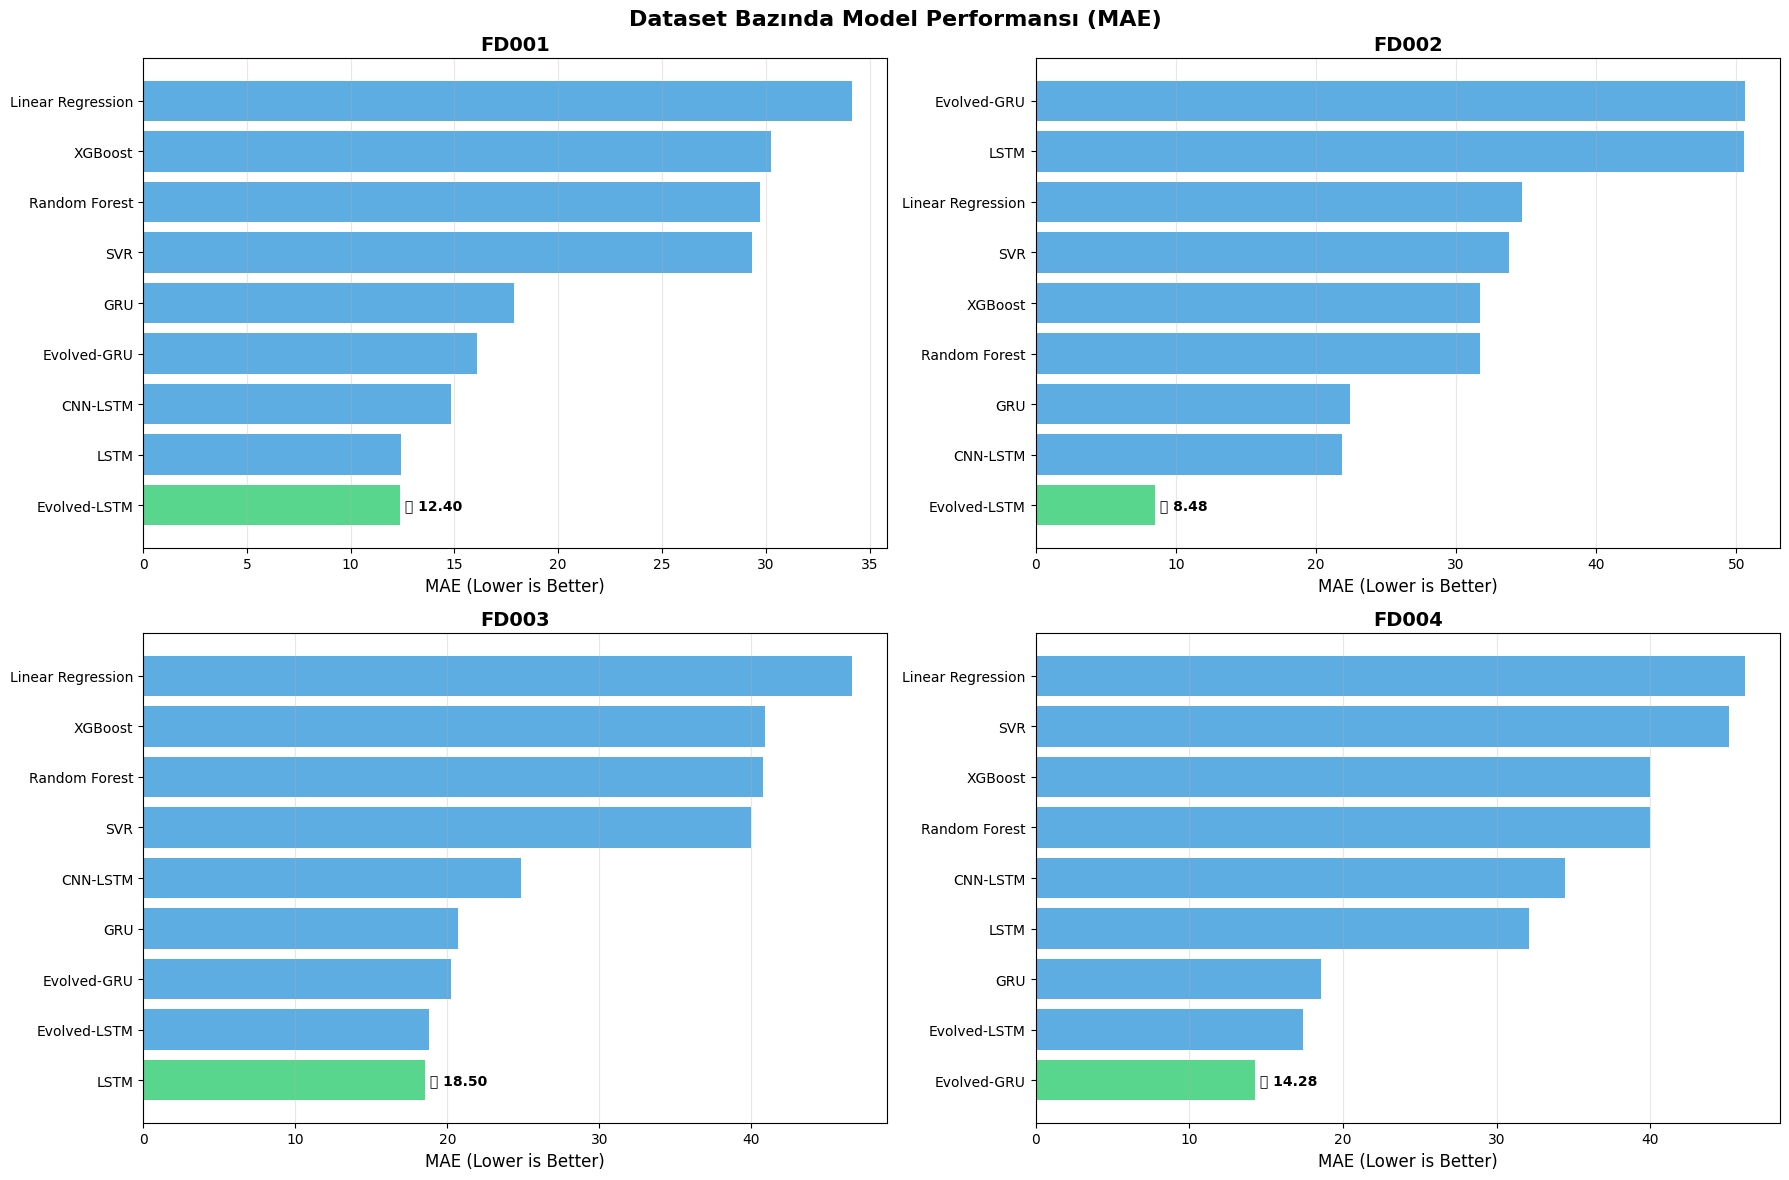

💾 Grafik 'model_comparison_mae.png' olarak kaydedildi


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Dataset Bazında Model Performansı (MAE)', fontsize=16, fontweight='bold')

for idx, (ds_name, ax) in enumerate(zip(['FD001', 'FD002', 'FD003', 'FD004'], axes.flatten())):
    data = results_df[results_df['Dataset'] == ds_name].sort_values('MAE')
    
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(data))]
    
    ax.barh(data['Model'], data['MAE'], color=colors, alpha=0.8)
    ax.set_xlabel('MAE (Lower is Better)', fontsize=12)
    ax.set_title(f'{ds_name}', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # En iyi modeli vurgula
    best_model = data.iloc[0]['Model']
    best_mae = data.iloc[0]['MAE']
    ax.text(best_mae, 0, f' ⭐ {best_mae:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_mae.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Grafik 'model_comparison_mae.png' olarak kaydedildi")

### 9.2 Model Bazında Ortalama Performans

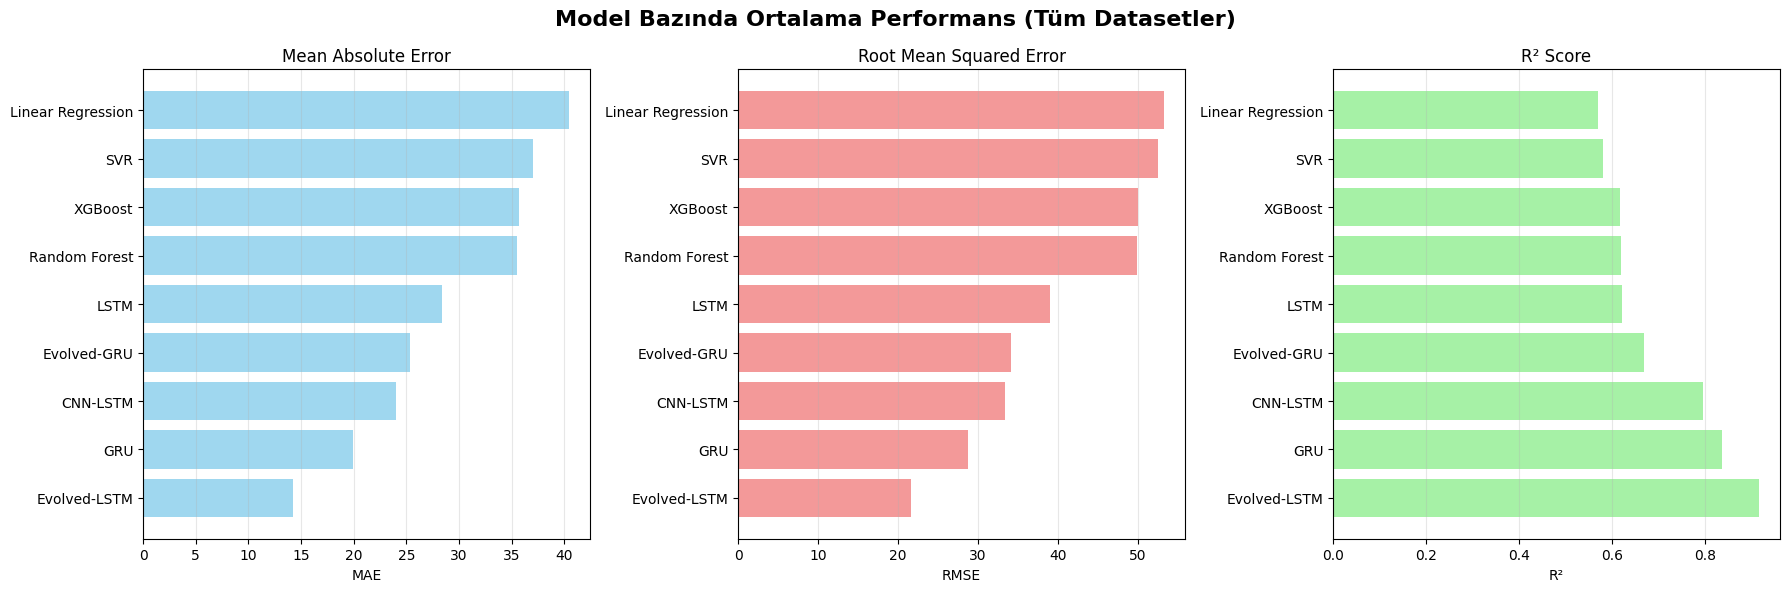

💾 Grafik 'model_comparison_avg.png' olarak kaydedildi


In [15]:
# Her model için ortalama performans
model_avg = results_df.groupby('Model')[['MAE', 'RMSE', 'R2']].mean().sort_values('MAE')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Bazında Ortalama Performans (Tüm Datasetler)', fontsize=16, fontweight='bold')

# MAE
axes[0].barh(model_avg.index, model_avg['MAE'], color='skyblue', alpha=0.8)
axes[0].set_xlabel('MAE')
axes[0].set_title('Mean Absolute Error')
axes[0].grid(axis='x', alpha=0.3)

# RMSE
axes[1].barh(model_avg.index, model_avg['RMSE'], color='lightcoral', alpha=0.8)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Root Mean Squared Error')
axes[1].grid(axis='x', alpha=0.3)

# R2
axes[2].barh(model_avg.index, model_avg['R2'], color='lightgreen', alpha=0.8)
axes[2].set_xlabel('R²')
axes[2].set_title('R² Score')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_avg.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Grafik 'model_comparison_avg.png' olarak kaydedildi")

### 9.3 Heatmap - Model vs Dataset

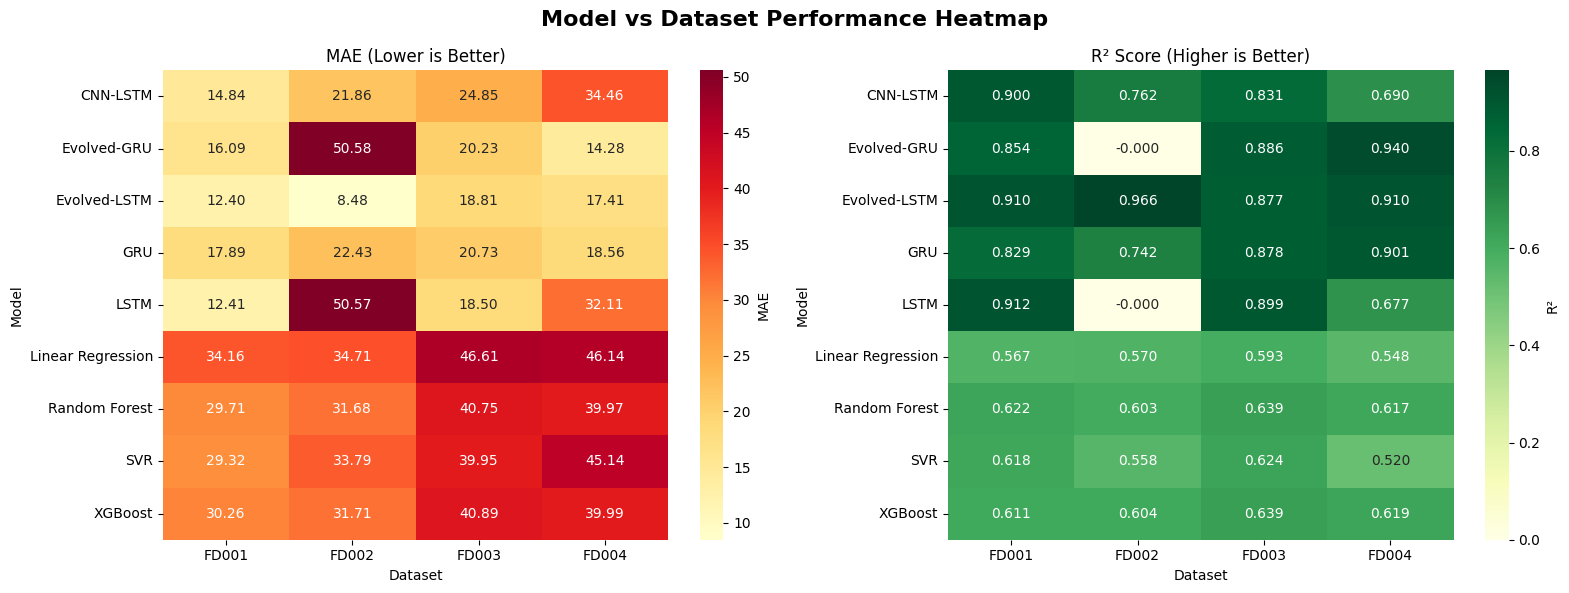

💾 Grafik 'model_comparison_heatmap.png' olarak kaydedildi


In [16]:
# Pivot table oluştur
pivot_mae = results_df.pivot(index='Model', columns='Dataset', values='MAE')
pivot_r2 = results_df.pivot(index='Model', columns='Dataset', values='R2')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model vs Dataset Performance Heatmap', fontsize=16, fontweight='bold')

# MAE Heatmap
sns.heatmap(pivot_mae, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'MAE'})
axes[0].set_title('MAE (Lower is Better)')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Model')

# R2 Heatmap
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='YlGn', ax=axes[1], cbar_kws={'label': 'R²'})
axes[1].set_title('R² Score (Higher is Better)')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.savefig('model_comparison_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Grafik 'model_comparison_heatmap.png' olarak kaydedildi")

### 9.4 Eğitim Süresi Karşılaştırması

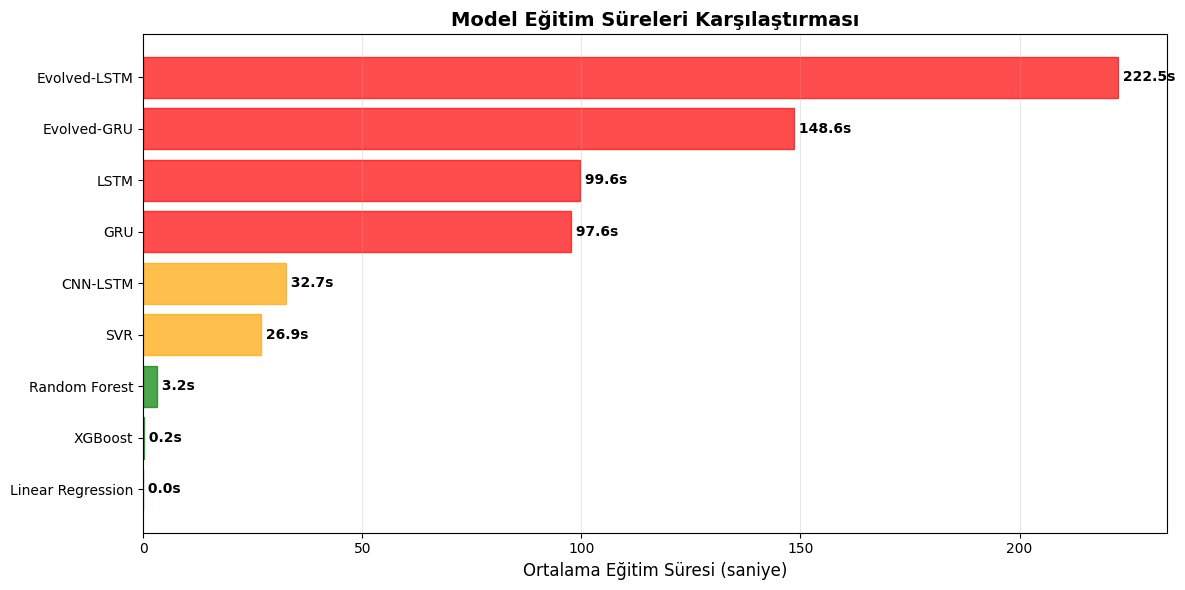

💾 Grafik 'model_training_time.png' olarak kaydedildi


In [17]:
# Ortalama eğitim süresi
time_avg = results_df.groupby('Model')['Train_Time'].mean().sort_values()

plt.figure(figsize=(12, 6))
bars = plt.barh(time_avg.index, time_avg.values, color='steelblue', alpha=0.8)

# Renklendirme (hızlı: yeşil, yavaş: kırmızı)
colors = ['green' if t < 10 else 'orange' if t < 60 else 'red' for t in time_avg.values]
for bar, color in zip(bars, colors):
    bar.set_color(color)
    bar.set_alpha(0.7)

plt.xlabel('Ortalama Eğitim Süresi (saniye)', fontsize=12)
plt.title('Model Eğitim Süreleri Karşılaştırması', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Değerleri ekle
for i, v in enumerate(time_avg.values):
    plt.text(v, i, f' {v:.1f}s', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_training_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Grafik 'model_training_time.png' olarak kaydedildi")

## 10. En İyi Modeller Özeti

In [18]:
print("\n" + "="*100)
print("🏆 EN İYİ MODELLER")
print("="*100)

# Her dataset için en iyi model
for ds_name in ['FD001', 'FD002', 'FD003', 'FD004']:
    best = results_df[results_df['Dataset'] == ds_name].sort_values('MAE').iloc[0]
    print(f"\n📊 {ds_name}:")
    print(f"   🥇 Model: {best['Model']}")
    print(f"   📈 MAE: {best['MAE']:.2f} | RMSE: {best['RMSE']:.2f} | R²: {best['R2']:.3f}")

# Genel en iyi model (tüm datasetlerde ortalama)
overall_best = results_df.groupby('Model')['MAE'].mean().sort_values().iloc[0]
overall_best_model = results_df.groupby('Model')['MAE'].mean().sort_values().index[0]

print(f"\n\n🌟 GENEL EN İYİ MODEL (Ortalama MAE): {overall_best_model}")
print(f"   📊 Ortalama MAE: {overall_best:.2f}")

print("\n" + "="*100)


🏆 EN İYİ MODELLER

📊 FD001:
   🥇 Model: Evolved-LSTM
   📈 MAE: 12.40 | RMSE: 18.29 | R²: 0.910

📊 FD002:
   🥇 Model: Evolved-LSTM
   📈 MAE: 8.48 | RMSE: 11.49 | R²: 0.966

📊 FD003:
   🥇 Model: LSTM
   📈 MAE: 18.50 | RMSE: 29.26 | R²: 0.899

📊 FD004:
   🥇 Model: Evolved-GRU
   📈 MAE: 14.28 | RMSE: 20.11 | R²: 0.940


🌟 GENEL EN İYİ MODEL (Ortalama MAE): Evolved-LSTM
   📊 Ortalama MAE: 14.28

